In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from FAPT import *

s = Simulation()
s.order = 2
N_t = 150
tg = 150
tlist = np.linspace(0, tg, N_t)
sigma = 0.1

# compute cos params
cos_amp, cos_wd = compute_cos_params(s, tg)
heff_params = s.heff(cos_wd, cos_amp)
Delta = heff_params[2][2] - heff_params[0][0]
# rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case
rrr, Delta, cos_wd

TypeError: Heff_Floquet_summed() got multiple values for argument 'V0'

In [ ]:
# ==============================================================================
# ENERGIEWERTE SORTIERT MIT URSPRÜNGLICHEM INDEX, PHOTONENANZAHL UND DETUNING
# ==============================================================================

# Simulation-Instanz erstellen
sim = Simulation()

# Beispiel-Drive-Frequenz wd definieren (in GHz)
wd_ghz = sim.res_freq_static  
wd_rad = wd_ghz * 2 * np.pi

# Eigenwerte flachklopfen und aufsteigend sortieren
evals_flat = sim.E_array.flatten()
sorted_indices = np.argsort(evals_flat)

print(f"Referenz Drive-Frequenz wd: {wd_ghz:.6f} GHz\n")
header = f"{'Sort.':<5} | {'Orig. Index':<11} | {'State |q1,c,q2>':<13} | {'E (GHz)':<10} | {'E / wd':<8} | {'Photon N':<8} | {'Detuning (GHz)':<14}"
print(header)
print("-" * len(header))

for sort_idx, orig_idx in enumerate(sorted_indices):
    # 1D-Index zurück in 3D-Zustandsindizes umrechnen
    q1, c, q2 = np.unravel_index(orig_idx, (sim.dim_q1, sim.dim_c, sim.dim_q2))
    
    # Energien in GHz
    E_rad = evals_flat[orig_idx]
    E_ghz = E_rad / (2 * np.pi)
    
    # Verhältnis E / wd und zugeordnete Photonenanzahl N
    ratio = E_rad / wd_rad if wd_rad != 0 else 0.0
    photon_n = int(np.round(ratio))
    
    # Detuning zur N-Photonen-Resonanz: E - N * wd (in GHz)
    detuning_ghz = E_ghz - (photon_n * wd_ghz)
    
    state_str = f"|{q1},{c},{q2}>"
    print(f"{sort_idx:<5} | {orig_idx:<11} | {state_str:<13} | {E_ghz:<10.5f} | {ratio:<8.3f} | {photon_n:<8d} | {detuning_ghz:<+14.6f}")

Referenz Drive-Frequenz wd: 0.706337 GHz

Sort. | Orig. Index | State |q1,c,q2> | E (GHz)    | E / wd   | Photon N | Detuning (GHz)
-----------------------------------------------------------------------------------------
0     | 0           | |0,0,0>       | -0.00332   | -0.005   | 0        | -0.003324     
1     | 1           | |0,0,1>       | 3.09362    | 4.380    | 4        | +0.268276     
2     | 9           | |1,0,0>       | 3.79996    | 5.380    | 5        | +0.268276     
3     | 3           | |0,1,0>       | 4.31950    | 6.115    | 6        | +0.081476     
4     | 2           | |0,0,2>       | 5.98357    | 8.471    | 8        | +0.332873     
5     | 10          | |1,0,1>       | 6.89489    | 9.761    | 10       | -0.168472     
6     | 4           | |0,1,1>       | 7.41036    | 10.491   | 10       | +0.346993     
7     | 18          | |2,0,0>       | 7.41892    | 10.503   | 11       | -0.350785     
8     | 12          | |1,1,0>       | 8.09096    | 11.455   | 11       | +

In [ ]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg):
    ht, ht_args = h_target(Delta, rrr, tg, sigma_r = sigma)
    return ht, ht_args
ht, args = compute_htarget(tg)

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


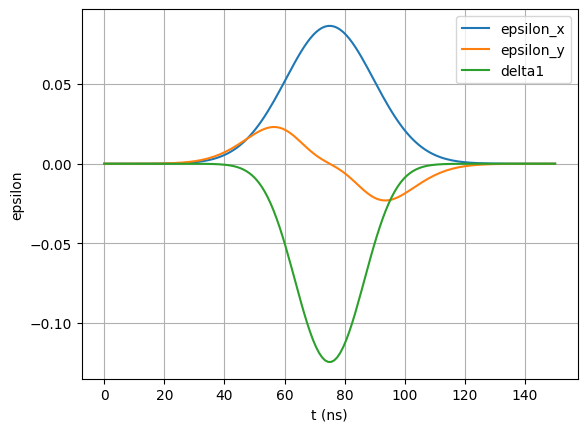

In [ ]:
ex = np.array([args[0](t) for t in tlist])
ey = np.array([args[1](t)*10 for t in tlist])
d1 = np.array([args[2](t) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

In [ ]:
import pickle
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi] # TODO anpassen
amp_real_max = 1.0 * 2 * np.pi
amp_imag_max = amp_real_max / 8
amp_real_range = (-amp_real_max, amp_real_max)
amp_imag_range = (-amp_imag_max, amp_imag_max)

# Load coefficients
with open(coeff_file, 'rb') as f:
    coefficients_data = pickle.load(f)
coeffs01 = coefficients_data['coeffs01']
coeffs00 = coefficients_data['coeffs00']
coeffs11 = coefficients_data['coeffs11']
# coeffs12 = coefficients_data['coeffs12']
coeffs22 = coefficients_data['coeffs22']
# coeffs02 = coefficients_data['coeffs02']
print(f"Coefficients loaded from {coeff_file}")

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs


Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [ ]:
from scipy.optimize import least_squares

def find_parameter_change_fit(heff_t, prev_solution, t, dt):
    if not prev_solution:
        prev_solution = [cos_wd,cos_amp,0]
    def residuals(x):
        wd, ar, ai = x
        amp = ar + 1j*ai        
        heff_00 = heff_fit(coeffs00, wd, amp)
        heff_11 = heff_fit(coeffs11,wd, amp)
        heff_01 = heff_fit(coeffs01,wd, amp)
        deltadiff = (heff_00 - heff_11) - (heff_t[0,0] - heff_t[1,1])
        omega_diff = heff_01 - heff_t[0,1]

        return np.array([
            abs(deltadiff),
            np.real(omega_diff),
            np.imag(omega_diff)])
    res = least_squares(residuals, x0=[prev_solution[0], prev_solution[1], prev_solution[2]], 
                        bounds=([wd_range[0], amp_real_range[0], amp_imag_range[0]], 
                                [wd_range[1], amp_real_range[1], amp_imag_range[1]]))
    return {"dw": res.x[0], "dar": res.x[1], "dai": res.x[2]}

# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

drive_signal_func gives the time dependant DRAG amplitude 

mesolve cannot deal with the difficult heff_modulated / pulse_shape_modulated functions as a parameter, so instead we precompute values and then simply interpolate between the defined values.

In [ ]:
# test difference between direct and perfect simulation
ht, _ = compute_htarget(tg)
ht_func = sum_list(ht)

def compute_pulse_shape(tlist, ht_func):
    prev_sol = None
    drive_freq_precomputed = []
    drive_amp_real_precomputed = []
    drive_amp_imag_precomputed = []
    dt = tg / N_t
    for t in tqdm(tlist):
        res = find_parameter_change_fit(ht_func(t), prev_sol, t, dt)
        freq= res['dw']
        amp_real = res['dar']
        amp_imag = res['dai']
        drive_freq_precomputed.append(freq)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
        prev_sol = [res['dw'], amp_real, amp_imag]
    return np.array(drive_freq_precomputed), np.array(drive_amp_real_precomputed), np.array(drive_amp_imag_precomputed)

force_computation = True
heff_file = coeff_dir / f"precomputed_heff_modulated{tg}_{N_t}.pkl"

if heff_file.exists() and not force_computation:
    with open(heff_file, 'rb') as f:
        heff_data = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
    drive_freq_precomputed = heff_data['frequency']
    drive_amp_real_precomputed = heff_data['amplitude_real']
    drive_amp_imag_precomputed = heff_data['amplitude_imag']
else:
    drive_freq_precomputed, drive_amp_real_precomputed, drive_amp_imag_precomputed = compute_pulse_shape(tlist, ht_func)
    heff_data = {
        'frequency': drive_freq_precomputed,
        'amplitude_real': drive_amp_real_precomputed,
        'amplitude_imag': drive_amp_imag_precomputed
    }
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_data, f)
    print(f"frequency and amplitudes saved to {heff_file}")

100%|██████████| 150/150 [00:00<00:00, 1922.80it/s]

frequency and amplitudes saved to /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated150_150.pkl


In [ ]:
def drive_signal_interp(t, freq = drive_freq_precomputed, amp_real = drive_amp_real_precomputed, amp_imag = drive_amp_imag_precomputed):
    if t <= tlist[0]:
        return [freq[0],0]
    if t >= tlist[-1]:
        return [freq[-1],0]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    wd = (1 - alpha) * freq[idx] + alpha * freq[idx + 1]
    ar = (1 - alpha) * amp_real[idx] + alpha * amp_real[idx + 1]
    ai = (1 - alpha) * amp_imag[idx] + alpha * amp_imag[idx + 1]
    return [wd, (ar + 1j*ai)]

In [ ]:

def plot_tg_fid_curve_direct(n, tg_min = 200, tg_max = 1000):
    lf_pop = []
    lf = []
    lf_pop_sambe = []
    ldiff = []
    ltg = np.linspace(tg_min, tg_max, n)
    for tg in tqdm(ltg):
        tlist = np.linspace(0, tg, N_t)
        ht, _ = compute_htarget(tg)
        ht_func = sum_list(ht)
        freq, amp_real, amp_imag = compute_pulse_shape(tlist, ht_func)
        def signal(t, args=None):
            s = drive_signal_interp(t, freq=freq, amp_imag=amp_imag, amp_real = amp_real)
            return np.real(s[1]) * np.cos(s[0]*t) + np.imag(s[1]) * np.sin(s[0]*t)
        lh = [s.H0, [s.V1, lambda t: signal(t)]]
        # f = extract_fidelity(lh, tlist, s=s)
        fpop = extract_pop_fid(lh, tlist, s=s)['iswap_fidelity']
        fpop_sambe = extract_pop_fid(ht_func, tlist)['iswap_fidelity']
        lf_pop.append(fpop)
        # lf.append(1-f)
        lf_pop_sambe.append(fpop_sambe)
        ldiff.append(fpop_sambe - fpop)
    ax = plt.subplot()
    plt.plot(ltg, np.array(ldiff), label='fidelity pop difference', color='green')
    plt.plot(ltg, np.array(lf_pop_sambe), label='fidelity sambe', color='red')
    plt.plot(ltg, np.array(lf_pop), label='fidelity direct', color='blue')
    # plt.plot(ltg, lf, label='infidelity', color='red')
    plt.xlabel('t_g (ns)')
    plt.ylabel('infidelity')
    # ax.set_yscale('log')
    plt.legend()
    plt.grid(True)
# plot_tg_fid_curve_direct(2)
plt.show()


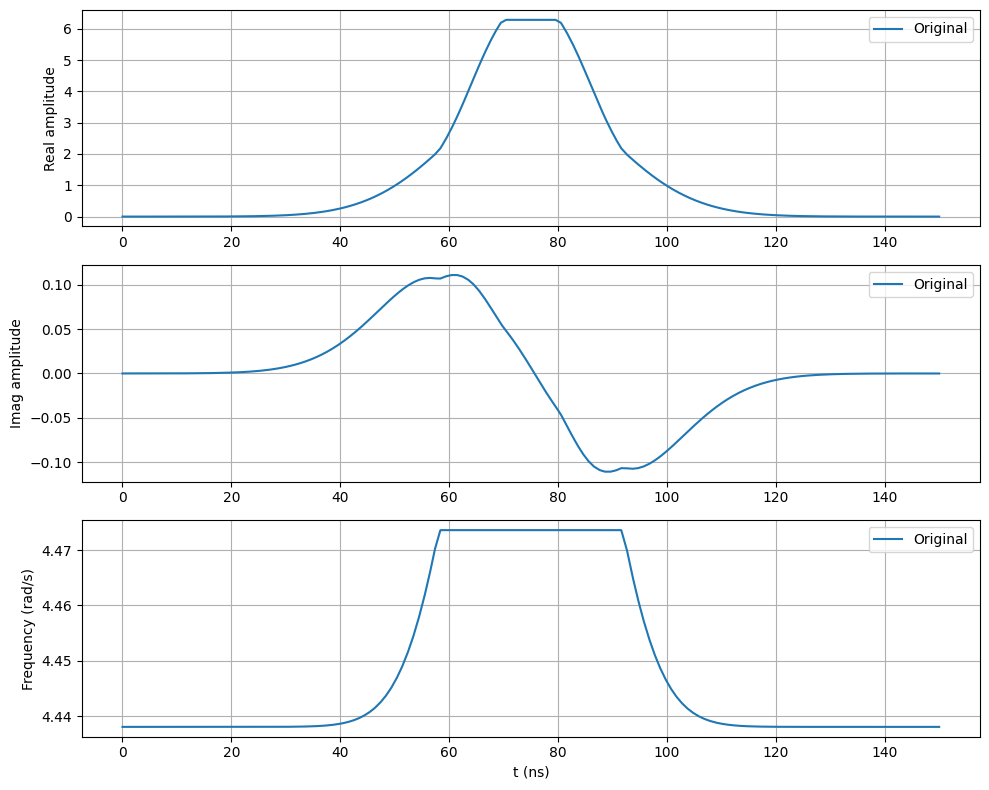

In [ ]:
def plot_drive_components(t_end=tg, n=2000):
    t_vals = np.linspace(0, t_end, n)
    amp_real = np.array([drive_signal_interp(t)[1].real for t in t_vals])
    amp_imag = np.array([drive_signal_interp(t)[1].imag for t in t_vals])
    freq = np.array([drive_signal_interp(t)[0] for t in t_vals])

    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    axes[0].plot(t_vals, amp_real, label="Original")
    axes[0].set_ylabel("Real amplitude")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t_vals, amp_imag, label="Original")
    axes[1].set_ylabel("Imag amplitude")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(t_vals, freq, label="Original")
    axes[2].set_ylabel("Frequency (rad/s)")
    axes[2].set_xlabel("t (ns)")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
plot_drive_components()

with the heff_modulated_interp function, the extraction of fidelity measurements can be done fast. To test for the right adoption of h_target, we compare fidelities for h_t, h_modulated and the raw hamiltonian with the given drive signal (h_drive). In the following those 3 cases will correspond to the values fid_engineered, fid_modulated, fid_drive.

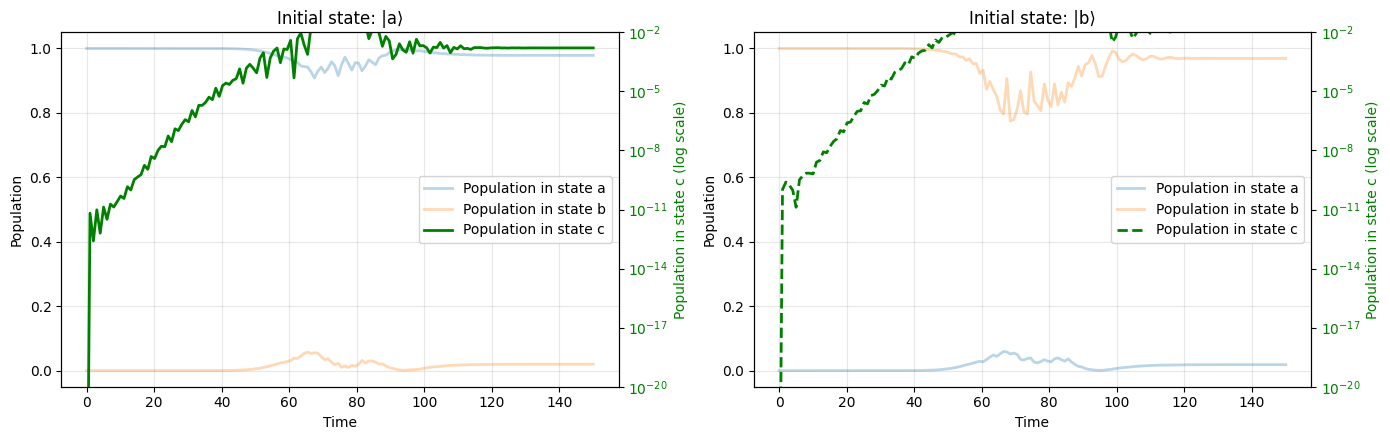

infidelity driven: pop: 9.81e-01


In [ ]:
# simulate the result directly over H0 and V1 from s 
def signal(t, args=None):
    s = drive_signal_interp(t)
    return (np.real(s[1]) * np.cos((s[0])*t) + np.imag(s[1]) * np.sin(s[0]*t))
lh = [s.H0, [s.V1, signal]]
# f_d = extract_fidelity(lh, tlist, s=s)
fpop_d = extract_pop_fid(lh, tlist, plot=True, plot_c=True, s=s)['iswap_fidelity']
print(f"infidelity driven: pop: {(1-fpop_d):.2e}")

Test the predictive power of the full dwd-, da- dependent Floquet Theory. Since the pulse shape is computed only with the dwd-dependency, a precise Floquet prediction should predict some off resonance that resembles the off resonance seen in the direct simulation before. 

In [ ]:
MODE = "on_the_fly"  # 'on_the_fly' oder 'precompute'

# s.resonances[s.state_d]=4
# s.sd = len(s.resonances)  # Dimension des effektiven Raums anpassen!

def calc_H(t, dt=tlist[1] - tlist[0]):
    """Berechnet H_eff für einen beliebigen Zeitpunkt t."""
    t_prev = max(tlist[0], t - dt)
    wd, amp = drive_signal_interp(t)
    wd_prev, amp_prev = drive_signal_interp(t_prev)
    
    dwd = (wd - wd_prev) / dt if t > tlist[0] else 0.0
    damp = (amp - amp_prev) / dt if t > tlist[0] else 0.0
    V_posharm = s.V1_dressed_array
    V0 = None
    h = Heff_Floquet_total_matrix_summed(
        s.order, wd, amp, s.resonances, s.E_array, V_posharm,V0=V0, 
        dwd=dwd, dA=damp, t=t, analytics=False, 
        include_g_correction=True, 
        include_geometric=True, 
        include_micromotion=False
    )
    return Qobj(np.asarray(h, dtype=complex))

# --- Modi Setup ---
if MODE == "precompute":
    Hs = [calc_H(t) for t in tqdm(tlist, desc="Precomputing H_eff")]
    def H_func(t):
        idx = min(np.searchsorted(tlist, t), len(tlist) - 1)
        return Hs[idx]
else:
    def H_func(t, args=None):
        return calc_H(np.clip(t, tlist[0], tlist[-1]))


print("len(resonances) =", len(s.resonances))
print("resonances =", s.resonances)

print("H0 shape =", s.H0.shape)

for i in s.resonances:
    print(i, s.E_states[i].shape)

# --- Simulation ---
# fidelity_result = extract_pop_fid([H_func], tlist, debug=True, plot=True, cut=True, s=s)
# print(f"fidelity pop: {1 - fidelity_result['iswap_fidelity']:.2e}")

len(resonances) = 3
resonances = {1: 0, 9: 1, 3: 2}
H0 shape = (27, 27)
1 (27, 1)
9 (27, 1)
3 (27, 1)


 99%|█████████▉| 149/150 [03:04<00:01,  1.24s/it]


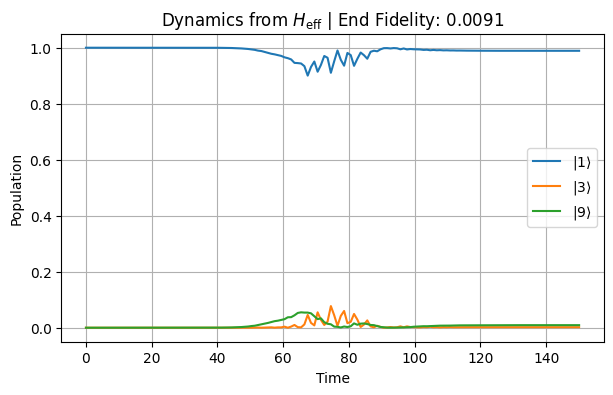

fid: 9.91e-01
bei Nt=200 ist 1-fid=4.84e-01 
bei rH3 rW2 folgt 4.84e-01


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def run_and_plot_swap_simulation(rH, rW, drive_signal_interp, resonances, E_array, V1_dressed_array, E_states, state_a, state_b, tlist, include_geometric=True, include_micromotion=True, include_g_correction=False, analytics=False, substeps=5, show_plot=True):
    
    psi = Psi_t_from_Heff(rH, rW, drive_signal_interp, resonances, E_array, V1_dressed_array, E_states[state_a], tlist, None, None, include_geometric, include_micromotion, include_g_correction, analytics, substeps)

    pop = np.abs(psi)**2
    fidelity = pop[state_b, -1]

    if show_plot:
        plt.figure(figsize=(7, 4))
        for n in range(pop.shape[0]):
            if pop[n].max() > 1e-4:
                plt.plot(tlist, pop[n], label=fr"$|{n}\rangle$")
        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title(rf"Dynamics from $H_{{\rm eff}}$ | End Fidelity: {fidelity:.4f}")
        plt.grid(True)
        plt.legend()
        plt.show()

    return fidelity

# Aufruf:
fid = run_and_plot_swap_simulation(3, 2, drive_signal_interp, s.resonances, s.E_array, s.V1_dressed_array, s.E_states, s.state_a, s.state_b, tlist)
print(f"fid: {1-fid:.2e}")
print("bei Nt=200 ist 1-fid=4.84e-01 ")
print("bei rH3 rW2 folgt 4.84e-01")

The simulation shows: dwd correction is important to achieve full population transfer. The population transfer becomes less ideal, when damp is also used to calculate the effective hamiltonian. However the change is much too small to account for the big off resonance in the driving scheme that can be seen in the direct simulation.

# Search for time dependent corrections

To check, which terms in the analytical derivation could be usefull, it is important to see which time derviative has the strongest impact on the deviation of direct simulation and modulated simulation. 

The change of $a_i$ does not seem promising

In [ ]:
dt = tg / N_t
def modulated_hamiltonian(t, args=None):
    s_before = drive_signal_interp(t-dt)    
    s_interp = drive_signal_interp(t)
    wd = s_interp[0]
    amp = s_interp[1]
    dwd = (wd-s_before[0])/dt
    damp = (amp-s_before[1])/dt
    dwd = 0
    damp = 0
    heff = Qobj(s.heff(wd, amp, dwd=dwd, da=damp, t=t))
    # Return the modulated signal: amplitude * (cos(wd*t) + i*sin(wd*t))
    return heff
# Extract fidelity using the population-based method
# fidelity_result = extract_pop_fid([modulated_hamiltonian], tlist, debug=True, plot=True, cut=True)

# Adapt for different Gate times

In [ ]:
import pickle
from pathlib import Path
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
from tqdm import tqdm


def compare_simulation_methods(tg, s, N_t=200, sigma=0.2, force_recompute=False):
    tlist = np.linspace(0, tg, N_t)

    # --- 1. Target & Parameter ---
    cos_amp, cos_wd = compute_cos_params(s, tg)
    heff_params = s.heff(cos_wd, cos_amp)
    Delta = heff_params[2][2] - heff_params[0][0]
    rrr = heff_params[1][2] / heff_params[0][1]

    ht, _ = h_target(Delta, rrr, tg, sigma_r=sigma)
    ht_func = lambda t: ht[0] + sum(h[0] * h[1](t) for h in ht[1:])

    # --- 2. Pulse Shape / Caching ---
    heff_file = coeff_dir / f"pulse_shape_tg{tg}_Nt{N_t}.pkl"

    if heff_file.exists() and not force_recompute:
        with open(heff_file, "rb") as f:
            data = pickle.load(f)
        freq, ar, ai = data["freq"], data["ar"], data["ai"]
    else:
        freq, ar, ai = [], [], []
        prev_sol = [cos_wd, cos_amp, 0]
        bounds = (
            [0.7 * 2 * np.pi, -2 * np.pi, -np.pi / 4],
            [0.712 * 2 * np.pi, 2 * np.pi, np.pi / 4],
        )

        for t in tqdm(tlist, desc=f"Pulse Shape (tg={tg})", leave=False):
            ht_t = ht_func(t)

            def res(x):
                w, a_r, a_i = x
                amp = a_r + 1j * a_i
                diff_diag = (
                    heff_fit(coeffs00, w, amp) - heff_fit(coeffs11, w, amp)
                ) - (ht_t[0, 0] - ht_t[1, 1])
                diff_off = heff_fit(coeffs01, w, amp) - ht_t[0, 1]
                return [abs(diff_diag), np.real(diff_off), np.imag(diff_off)]

            opt = least_squares(res, x0=prev_sol, bounds=bounds)
            prev_sol = opt.x
            freq.append(opt.x[0])
            ar.append(opt.x[1])
            ai.append(opt.x[2])

        freq, ar, ai = np.array(freq), np.array(ar), np.array(ai)
        # with open(heff_file, "wb") as f:
        #     pickle.dump({"freq": freq, "ar": ar, "ai": ai}, f)

    # fill_value="extrapolate" verhindert IndexErrors an den Rändern bei N_t > 1000
    f_wd = interp1d(
        tlist, freq, kind="linear", bounds_error=False, fill_value=(freq[0], freq[-1])
    )
    f_ar = interp1d(
        tlist, ar, kind="linear", bounds_error=False, fill_value=(ar[0], ar[-1])
    )
    f_ai = interp1d(
        tlist, ai, kind="linear", bounds_error=False, fill_value=(ai[0], ai[-1])
    )

    # QuTiP Signal: Garantiert IMMER einen reellen float-Wert
    def qutip_signal(t, args=None):
        w = float(f_wd(t))
        r = float(f_ar(t))
        i = float(f_ai(t))
        return r * np.cos(w * t) + i * np.sin(w * t)

    # Floquet Signal
    def drive_signal_interp(t):
        w = float(f_wd(t))
        amp = float(f_ar(t)) + 1j * float(f_ai(t))
        return [w, amp]

    # --- 4. Simulationen ---
    fid_direct = extract_pop_fid(
        [s.H0, [s.V1, qutip_signal]], tlist, plot=False, plot_c=False, s=s
    )["iswap_fidelity"]

    fid_floquet = run_and_plot_swap_simulation(
        2,
        1,
        drive_signal_interp,
        s.resonances,
        s.E_array,
        s.V1_dressed_array,
        s.E_states,
        s.state_a,
        s.state_b,
        tlist,
        show_plot=False,
    )

    diff = fid_direct - fid_floquet
    return {
        "fid_direct": fid_direct,
        "fid_floquet": fid_floquet,
        "diff": diff,
        "abs_diff": abs(diff),
    }

Sweeping gate times: 100%|██████████| 10/10 [00:45<00:00,  4.59s/it]


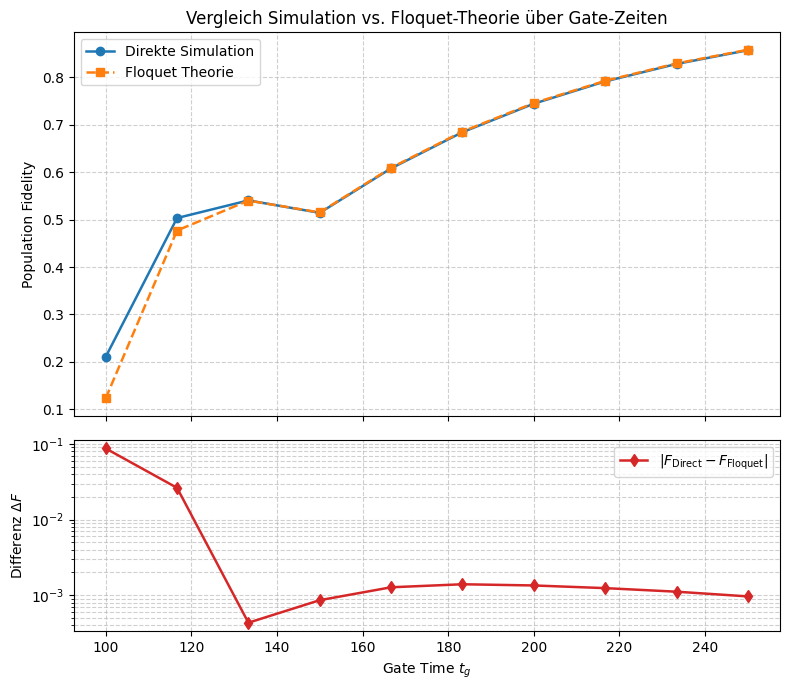

In [ ]:
# 1. Parameter Sweep
gate_times = np.linspace(100, 250, 10)

fids_direct = []
fids_floquet = []
abs_diffs = []


for tg in tqdm(gate_times, desc="Sweeping gate times"):
    res = compare_simulation_methods(tg, s, N_t = N_t)
    fids_direct.append(res["fid_direct"])
    fids_floquet.append(res["fid_floquet"])
    abs_diffs.append(res["abs_diff"])

# 2. Visualisierung
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# Top Plot: Erreichte Fidelities
ax1.plot(
    gate_times,
    fids_direct,
    "o-",
    label="Direkte Simulation",
    color="tab:blue",
    lw=1.8,
)
ax1.plot(
    gate_times,
    fids_floquet,
    "s--",
    label="Floquet Theorie",
    color="tab:orange",
    lw=1.8,
)
ax1.set_ylabel("Population Fidelity")
ax1.set_title("Vergleich Simulation vs. Floquet-Theorie über Gate-Zeiten")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Bottom Plot: Absolute Differenz (Methode-Abweichung)
ax2.plot(
    gate_times,
    abs_diffs,
    "d-",
    color="tab:red",
    lw=1.8,
    label=r"$|F_{\rm Direct} - F_{\rm Floquet}|$",
)
ax2.set_xlabel("Gate Time $t_g$")
ax2.set_ylabel(r"Differenz $\Delta F$")
ax2.set_yscale("log")  # Log-Skala macht feine Abweichungen sichtbar
ax2.grid(True, which="both", linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# Test the cosine prediction

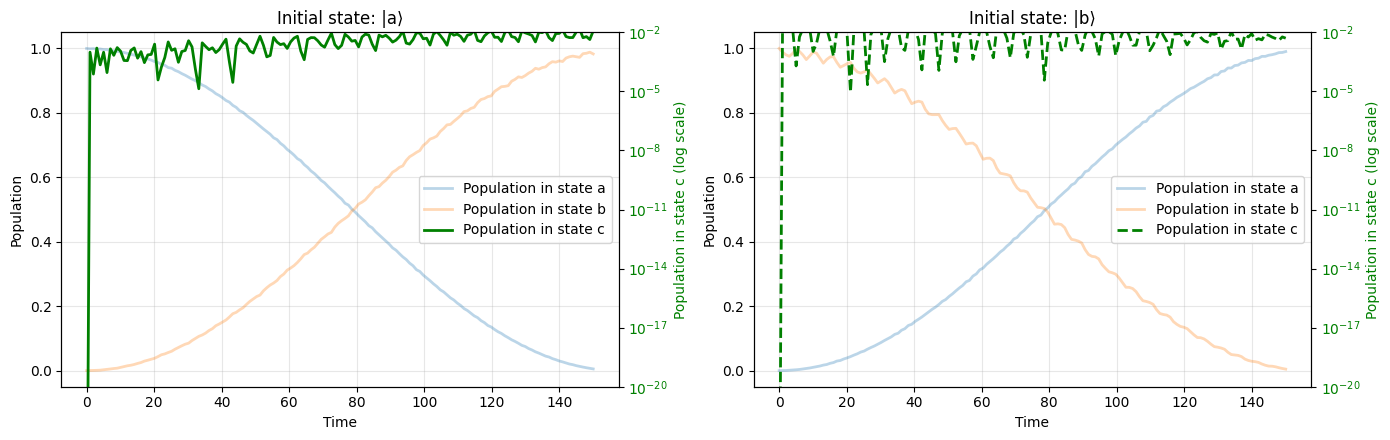

pop_fid: 1.34e-02


In [ ]:
lh = [s.H0, [s.V1, lambda t: cos_amp * np.cos(cos_wd * t)]]
fpop_d = extract_pop_fid(lh, tlist, plot=True, plot_c=True, s=s)['iswap_fidelity']
print(f"pop_fid: {1-fpop_d:.2e}")